Шлях до метаданих:
 ESC-50/meta/esc50.csv
Папка з аудіофайлами:
 ESC-50/audio
Папка для вихідних даних:
 ESC_subset
----------
Кількість записів у CSV:
 2000
Унікальні класи:
 ['dog' 'chirping_birds' 'vacuum_cleaner' 'thunderstorm' 'door_wood_knock'
 'can_opening' 'crow' 'clapping' 'fireworks' 'chainsaw' 'airplane'
 'mouse_click' 'pouring_water' 'train' 'sheep' 'water_drops'
 'church_bells' 'clock_alarm' 'keyboard_typing' 'wind' 'footsteps' 'frog'
 'cow' 'brushing_teeth' 'car_horn' 'crackling_fire' 'helicopter'
 'drinking_sipping' 'rain' 'insects' 'laughing' 'hen' 'engine' 'breathing'
 'crying_baby' 'hand_saw' 'coughing' 'glass_breaking' 'snoring'
 'toilet_flush' 'pig' 'washing_machine' 'clock_tick' 'sneezing' 'rooster'
 'sea_waves' 'siren' 'cat' 'door_wood_creaks' 'crickets']
----------
Вибрані класи:
 ['dog', 'chirping_birds']
Кількість вибраних файлів:
 80
----------


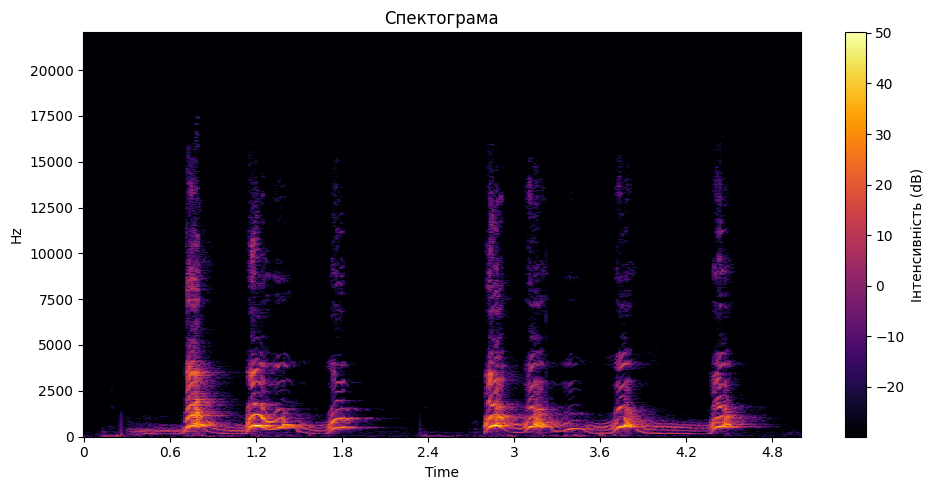

Виведення спектральної матриці:
 [[ -7.630028   -4.64977   -29.816301  ... -26.931288  -29.882416
  -29.882416 ]
 [ -9.029848   -5.0632706  -7.004228  ... -23.627033  -23.05935
  -28.23783  ]
 [-13.407719  -11.350106   -9.087509  ... -23.837437  -20.809559
  -22.381733 ]
 ...
 [-29.882416  -29.882416  -29.882416  ... -29.882416  -29.882416
  -29.882416 ]
 [-29.882416  -29.882416  -29.882416  ... -29.882416  -29.882416
  -29.882416 ]
 [-29.882416  -29.882416  -29.882416  ... -29.882416  -29.882416
  -29.882416 ]]


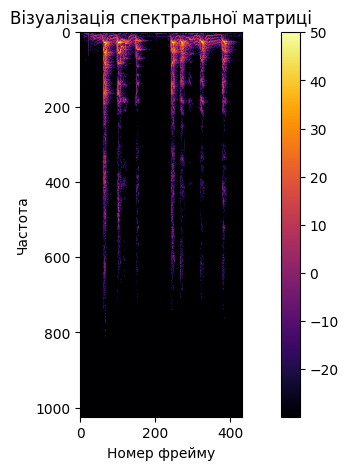

[array([ -4.64977 ,  12.78357 ,  11.837387, ..., -29.882416, -29.882416,
       -29.882416], dtype=float32), array([  3.7902637,  -4.8466735,   1.0096827, ..., -33.42882  ,
       -33.42882  , -33.42882  ], dtype=float32), array([ 16.620752,  16.664005,  16.686493, ..., -10.580624, -21.320086,
       -29.707062], dtype=float32), array([ 24.551327,  21.900232,  24.24938 , ..., -41.31844 , -41.31844 ,
       -41.31844 ], dtype=float32), array([  9.008617 ,   4.8947115,  10.709793 , ..., -32.19904  ,
       -32.19904  , -32.19904  ], dtype=float32), array([ 21.08036 ,  23.034405,  21.171219, ..., -30.347977, -30.347977,
       -30.347977], dtype=float32), array([  9.281199,  11.142196,  10.063869, ..., -39.87003 , -39.87003 ,
       -39.87003 ], dtype=float32), array([ -5.980543 ,  -5.210169 ,  -2.6506543, ..., -36.332283 ,
       -36.332283 , -36.332283 ], dtype=float32), array([  3.1245008 ,  -0.43979418,  -7.6224666 , ..., -36.374165  ,
       -36.374165  , -36.374165  ], dtype=float32

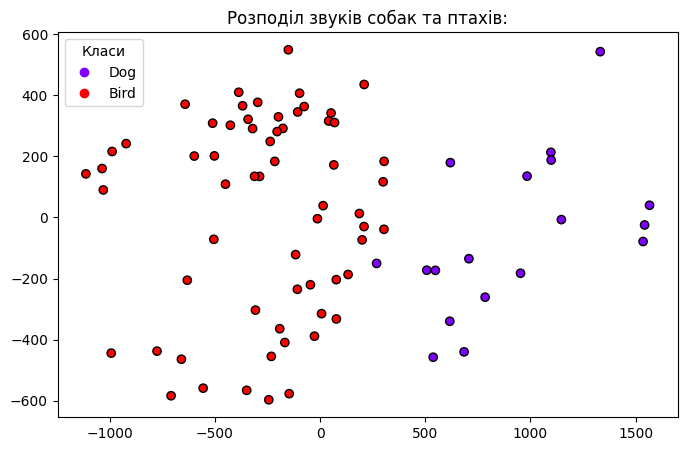

In [ ]:
import numpy as np
import pandas as pd
import librosa.display 
import multiprocessing
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import shutil
import librosa
import os


os.system("git clone https://github.com/karolpiczak/ESC-50.git")

path = "ESC-50/meta/esc50.csv" #шлях до даних
audio = "ESC-50/audio" #аудіо файли
output = "ESC_subset" #вихідні дані

print("Шлях до метаданих:\n", path)
print("Папка з аудіофайлами:\n", audio)
print("Папка для вихідних даних:\n", output)
print('----------')

os.makedirs(output, exist_ok=True)

#читаємо метадані
df = pd.read_csv(path)

print("Кількість записів у CSV:\n", len(df))
print("Унікальні класи:\n", df["category"].unique())
print('----------')

#залишаємо тільки потрібні класи
labels = ['dog', 'chirping_birds']
subset = df[df["category"].isin(labels)]

print("Вибрані класи:\n", labels)
print("Кількість вибраних файлів:\n", len(subset))
print('----------')

#копіюємо аудіофайли
for _, row in subset.iterrows():
    filename = row['filename']
    src = os.path.join(audio, filename)
    dst = os.path.join(output, filename)
    shutil.copy(src, dst)


#функція спектрограми
def spectrogram( samples, samples_rate, stride_ms = 10.0,
                          window_ms = 20.0, max_freq = None, eps = 1e-14):
    s = librosa.stft(samples) #розбиваємо на частини 
    s = np.abs(s)**2 #отримуємо частоти
    spectrogram = librosa.power_to_db(s)
    return spectrogram

#будуємо кольорову спекторграму
file_path = os.path.join(output, os.listdir(output)[0])

samples, sample_rate = librosa.load(file_path, sr=None)

spectr_matrix = spectrogram(samples, sample_rate)

plt.figure(figsize=(10,5))
librosa.display.specshow(spectr_matrix, sr=sample_rate, x_axis='time', y_axis='hz', cmap='inferno')
plt.colorbar(label="Інтенсивність (dB)")
plt.title("Спектограма")
plt.tight_layout()
plt.show()

#спектральна матриця 
print('Виведення спектральної матриці:\n', spectr_matrix)

#візуалізація спектральної матриці
def spect_show(spect_matrix):
    plt.figure(figsize=(10,5))
    plt.imshow(spect_matrix, cmap='inferno', interpolation='nearest')
    plt.colorbar()
    plt.title('Візуалізація спектральної матриці')
    plt.xlabel('Номер фрейму')
    plt.ylabel('Частота')
    plt.show()
spect_show(spectr_matrix)

#узагальнення та зменшення розміру спектрограми
def pooling_audio(mat, ksize = (4,4), method = 'max'):
    '''Зменьшення розміру спектограми.
    ksize = розмір вікна(рядок, стовбчик)'''
    m,  n = mat.shape
    kx, ky = ksize
    _mat = mat[:m//kx*kx, :n//ky*ky] #вирівнювання матриці 

    view = _mat.reshape(m//kx, kx, n//ky, ky) #зміна форми

    if method == 'max':
        return view.max(axis= (1,3))
    else:
        return view.mean(axis = (1,3))

#перетворення матриці спектрограми у вектор
all_features = []
file_list = os.listdir(output)

for file in file_list:
    f_path = os.path.join(output, file)
    y, sr = librosa.load(f_path, sr=None)
    spectr = spectrogram(y, sr)
    
    #зменшуємо розмірність 
    pooled = pooling_audio(spectr, ksize= (10,10))
    all_features.append(pooled.flatten())

#матриця
X = np.array(all_features)

#кластеризація даних
labels = SpectralClustering(n_clusters=2, affinity='nearest_neighbors').fit_predict(X)

#2D для графік
X_2d = PCA(n_components=2).fit_transform(X)

#результат
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='rainbow', edgecolors='k')
plt.legend(handles=scatter.legend_elements()[0], labels=['Dog', 'Bird'], title="Класи")
plt.title("Розподіл звуків собак та птахів:")
plt.show()


